## The exercise
The goal of this exercise is to find one or more signals that are hidden in a data set and then exploit the signal through a portfolio construction algorithm. Note that the exercise is not necessarily representative of your future work as a researcher in our team. Our aim is rather to see how you conduct research and how you communicate. Indeed, upon reception of your Notebook we might schedule a call to discuss the results orally.

## The data
The data for your research are provided in a gzipped csv file ```data_is.csv.gz```. The data represent three different assets, and have been artificially generated using a simple algorithm. A second, "out-of-sample" dataset ```data_oos.csv.gz``` will be provided upon the evaluation of the exercise. This latter was generated by the same rules, but with a different random seed.

The returns of the products have an approximate Gaussian distribution, with volatility that is constant in time. You will also find a small data error you may want to correct or at least take into account.

## Trading rules
Each asset has a bid and ask price, available at every minute. For simplicity, we assume that the products trade 24/7 with constant liquidity. You can buy any amount at the ask, and sell any amount at the bid.

Trading is instantaneous. This means that, for example, at 10:53am, you can buy at the ask quoted at 10:53am, using signals that incorporate prices up to and including 10:53am.

## Objective 1: Alpha research
The returns contain four different kinds of alpha. Their typical holding period is always less than a week. They follow fairly simple rules, similar to those you would find in real data. The signals are fairly strong, in order to help you identify them in this relatively small dataset. Try to find as many as possible, and prepare your notebook in such a way that you will be able to (orally) explain your thought process to a reviewer.

Here is some guidance on how you may want to proceed. First of all, bid and ask are provided separately to estimate trading cost. To find your alpha itself, you can safely focus on the mid price only. Second, consider the three kinds of information that you have available in the data:
* You have prices, and may want to construct signals based on past price or return history.
* You have timestamps, that could be used on their own.
* Finally, consider our choice of the three currency pairs we made available. They do share some currencies between them.

Some questions to help structure your notes:
* What metrics would you look at in order to find predictive signals based on the above?
* Have you managed to identify some anomalies, and which ones?
* How do these compare to your own experience with real data?

## Objective 2: Portfolio construction
Once you have one or more individual signals, make a portfolio, generate trades and calculate the PnL. Set your portfolio up such that you expect to obtain the highest out-of-sample Sharpe ratio you can. Even if you have not identified enough alpha to make a profitable strategy, go ahead and try to make a sensible portfolio to explain how you would have done so.

Some questions to help structure your notes:
* How did you combine your different alpha ideas?
* Did you alter them in some way order to beat the trading costs?
* What happens to the PnL if you increase the position sizes?

## Objective 1: Alpha research

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('data_is.csv.gz')
data = data.rename(columns={'Unnamed: 0': 'date'})
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')

data.head()

,bid_EURUSD,bid_AUDUSD,bid_EURAUD,ask_EURUSD,ask_AUDUSD,ask_EURAUD
date,,,,,,
2020-01-01 00:00:00,1.0012,1.0010,1.0000,1.0018,1.0016,1.0006
2020-01-01 00:01:00,1.0012,1.0014,1.0000,1.0018,1.0020,1.0006
2020-01-01 00:02:00,1.0012,1.0012,1.0000,1.0018,1.0018,1.0006
2020-01-01 00:03:00,1.0014,1.0014,1.0000,1.0020,1.0020,1.0006
2020-01-01 00:04:00,1.0014,1.0014,0.9998,1.0020,1.0020,1.0004


In [3]:
data.shape

(2102401, 6)

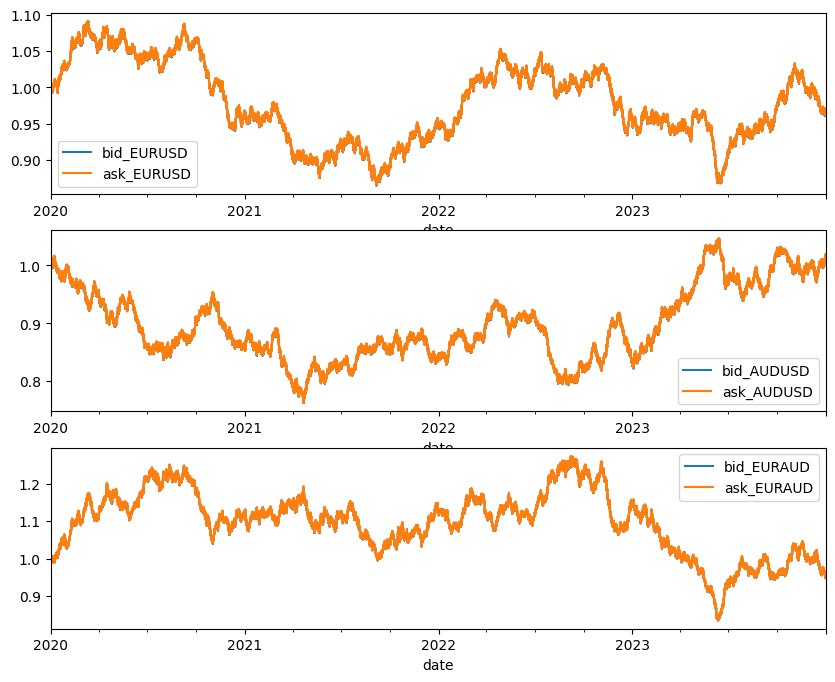

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8))

data[['bid_EURUSD', 'ask_EURUSD']].plot(ax=ax[0])
data[['bid_AUDUSD', 'ask_AUDUSD']].plot(ax=ax[1])
data[['bid_EURAUD', 'ask_EURAUD']].plot(ax=ax[2])

plt.show()

In [5]:
data.isna().sum(axis=0)

bid_EURUSD    0
bid_AUDUSD    0
bid_EURAUD    0
ask_EURUSD    0
ask_AUDUSD    0
ask_EURAUD    0
dtype: int64

<Axes: ylabel='date'>

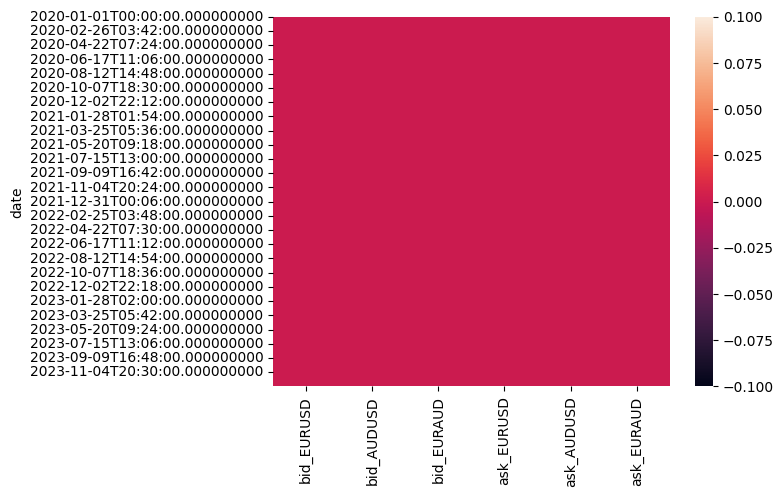

In [6]:
sns.heatmap(data.isna())

In [8]:
ccys = ['EURUSD', 'AUDUSD', 'EURAUD']

mid_list = []
for ccy in ccys:
    tmp_mid = pd.DataFrame((data[f'bid_{ccy}'] + data[f'ask_{ccy}']) / 2, columns=[f'mid_{ccy}'])
    mid_list.append(tmp_mid)
mid_data = pd.concat(mid_list, axis=1)

mid_ret = mid_data.pct_change()

In [9]:
(mid_ret * 100).describe().round(2)

,mid_EURUSD,mid_AUDUSD,mid_EURAUD
count,2102400.00,2102400.00,2102400.00
mean,-0.00,0.00,-0.00
std,0.01,0.02,0.02
min,-0.38,-0.10,-0.10
25%,0.00,-0.02,-0.02
50%,0.00,0.00,0.00
75%,0.00,0.02,0.02
max,0.07,0.09,0.11


### Alpha 1: Exploring Time Dependence

#### Validation: Autocorrelation Analysis with Heteroskedasticity Adjustment

We run an autocorrelation analysis by estimating OLS regressions of current returns on lagged returns. 

Since asset returns are notoriously heteroskedastic, we run a White test to check for heteroskedasticity.

If heteroskedasticity is present, this has no effect on the unbiasedness property of the OLS estimator (this property depends only on the relationship between the residuas and the covariates), but 

1. The OLS estimator is not BLUE anymore since there could exists a lower variance estimator
2. Standard errors of the estimates are biased now because it assumes constant variance
3. Since T-stat = beta / se(beta) and se(beta) is biased now, then T-stat is biased as well
4. Sice R2 = explained variance / total variance, then total variance becomes unstable and R2 unreliable

To account for this we use the Newey-West correction of the OLS estimator. This correction accounts for both heteroskedasticity in assets returns and residual dependencies induced by the lagged regression.

In [10]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

het_test_output = []
for colname in mid_ret.columns:
    for lag in range(1, 61):

        reg_df = mid_ret[[colname]].copy()
        reg_df[f'{colname}_lag{lag}'] = reg_df[colname].shift(lag)
        reg_df = reg_df.dropna()
        reg_df['const'] = 1

        reg_fit = sm.OLS(endog=reg_df[colname], exog=reg_df[f'{colname}_lag{lag}']).fit()

        test_het_white = het_white(resid=reg_fit.resid, exog=reg_df[['const', f'{colname}_lag{lag}']])

        lm_pvalue = test_het_white[1]

        tmp_output = {
                'ccy': colname,
                'lag': lag,
                'lm_pval': reg_fit.pvalues.item(),
            }

        het_test_output.append(
            pd.DataFrame([
                tmp_output
            ])
        )
het_test_output_df = pd.concat(het_test_output, axis=0)

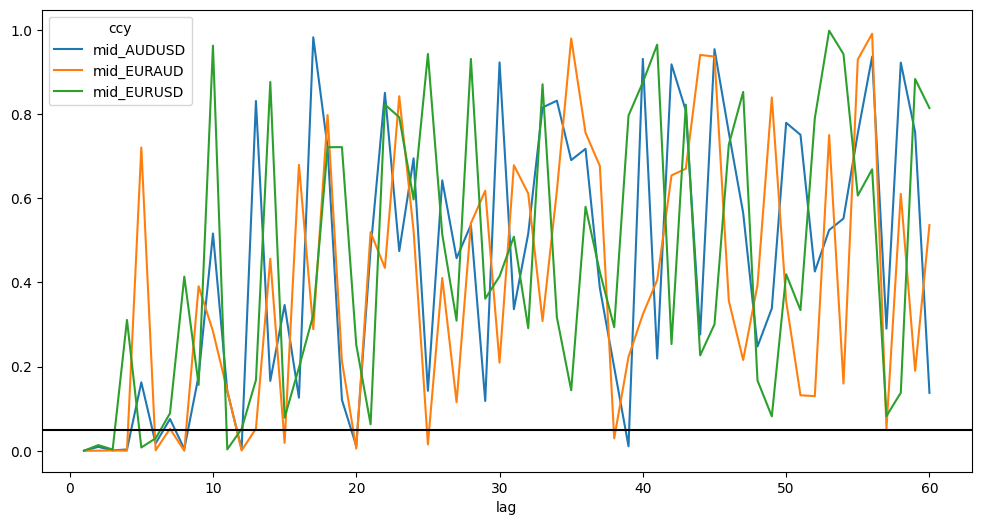

In [11]:
het_test_output_df.pivot(index='lag', columns='ccy', values='lm_pval').plot(figsize=(12, 6))
plt.axhline(0.05, color='black')

In [12]:
from statsmodels.tsa.stattools import acf

output = []
colname = next(iter(mid_ret.columns))
lag = next(iter(range(1, 61)))

reg_df = mid_ret[[colname]].copy()
reg_df[f'{colname}_lag{lag}'] = reg_df[colname].shift(lag)
reg_df = reg_df.dropna()
reg_fit = sm.OLS(endog=reg_df[colname], exog=reg_df[f'{colname}_lag{lag}']).fit()

acf_output = acf(reg_fit.resid, alpha=0.05)

acf_output_df = pd.DataFrame(acf_output[0], columns=['beta'])
acf_ci_output_df = pd.DataFrame(acf_output[1], columns=['lower_band', 'upper_band'])

acf_ci_output_df = acf_ci_output_df.loc[1:]

acf_ci_output_df['lag_count'] = [1 if ((x['lower_band'] < 0 and x['upper_band'] < 0) or (x['lower_band'] > 0 and x['upper_band'] > 0)) else 0 for idx, x in acf_ci_output_df.iterrows()]

maxlags = acf_ci_output_df['lag_count'].sum().item()

In [13]:
maxlags

10

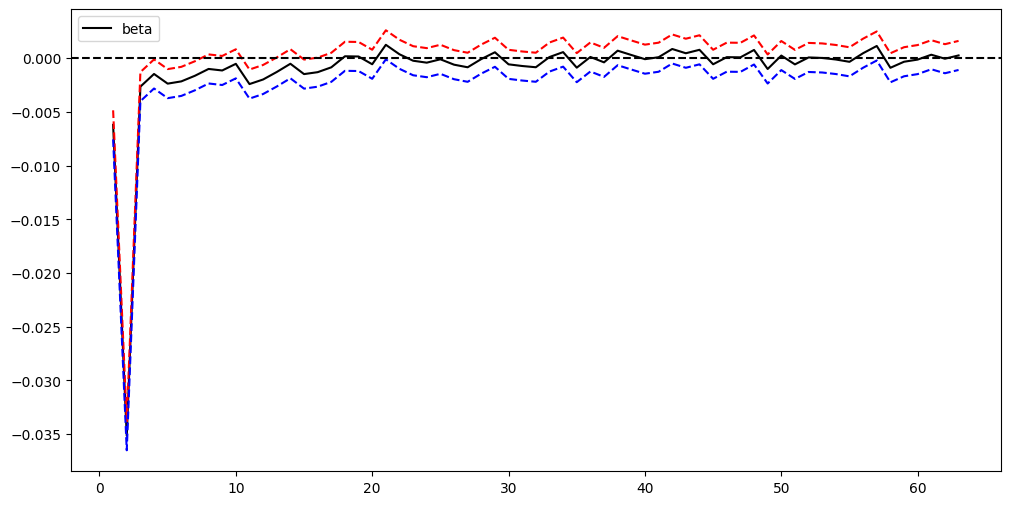

In [14]:
acf_output_df.loc[1:].plot(figsize=(12, 6), color='black')
acf_ci_output_df['upper_band'].loc[1:].plot(linestyle='--', color='r')
acf_ci_output_df['lower_band'].loc[1:].plot(linestyle='--', color='b')
plt.axhline(0, linestyle='--', color='black')

In [15]:
output = []
for colname in mid_ret.columns:
    for lag in range(1, 61):

        reg_df = mid_ret[[colname]].copy()
        reg_df[f'{colname}_lag{lag}'] = reg_df[colname].shift(lag)
        reg_df = reg_df.dropna()

        reg_fit = sm.OLS(endog=reg_df[colname], exog=reg_df[f'{colname}_lag{lag}']).fit()

        acf_output = acf(reg_fit.resid, alpha=0.05)

        acf_output_df = pd.DataFrame(acf_output[0], columns=['beta'])
        acf_ci_output_df = pd.DataFrame(acf_output[1], columns=['lower_band', 'upper_band'])

        acf_ci_output_df = acf_ci_output_df.loc[1:]

        acf_ci_output_df['lag_count'] = [1 if ((x['lower_band'] < 0 and x['upper_band'] < 0) or (x['lower_band'] > 0 and x['upper_band'] > 0)) else 0 for idx, x in acf_ci_output_df.iterrows()]

        maxlags = acf_ci_output_df['lag_count'].sum().item()

        reg_fit = sm.OLS(endog=reg_df[colname], exog=reg_df[f'{colname}_lag{lag}']).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})

        tmp_output = {
            'ccy': colname,
            'lag': lag,
            'beta': reg_fit.params.item(),
            'pval': reg_fit.pvalues.item(),
        }

        output.append(
            pd.DataFrame([
                tmp_output
            ])
        )
output_df = pd.concat(output, axis=0)

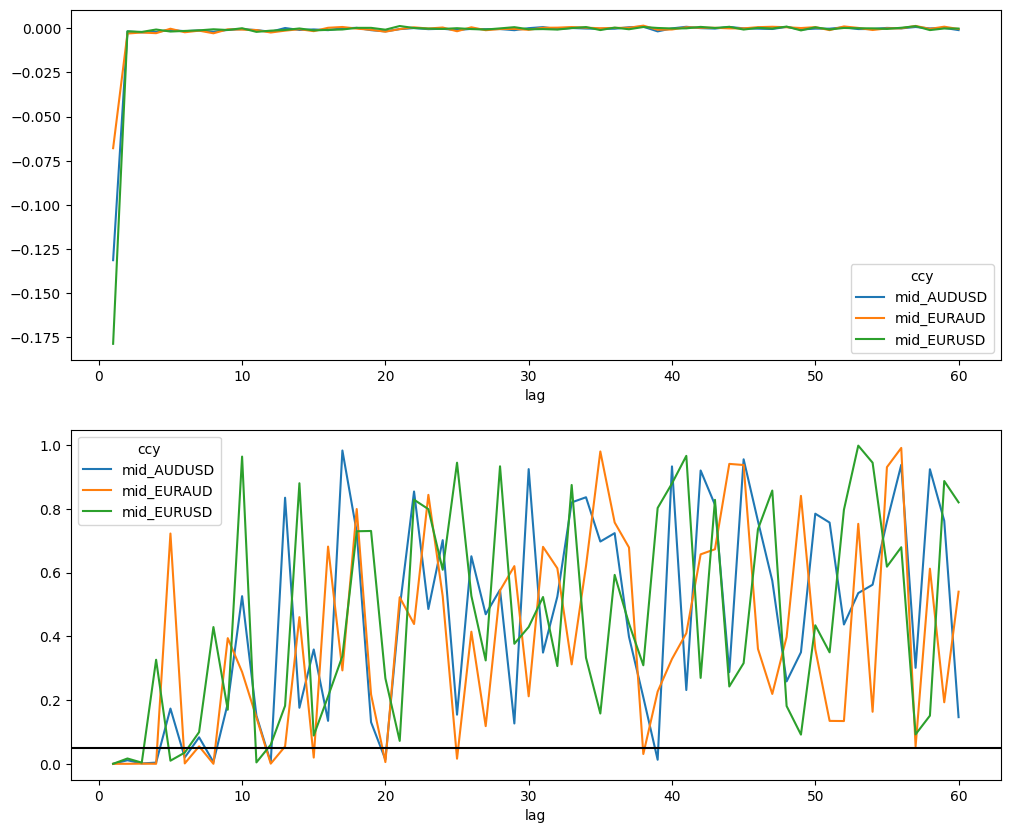

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

output_df.pivot(index='lag', columns='ccy', values='beta').plot(ax=ax[0])
output_df.pivot(index='lag', columns='ccy', values='pval').plot(ax=ax[1])
ax[1].axhline(0.05, color='black')

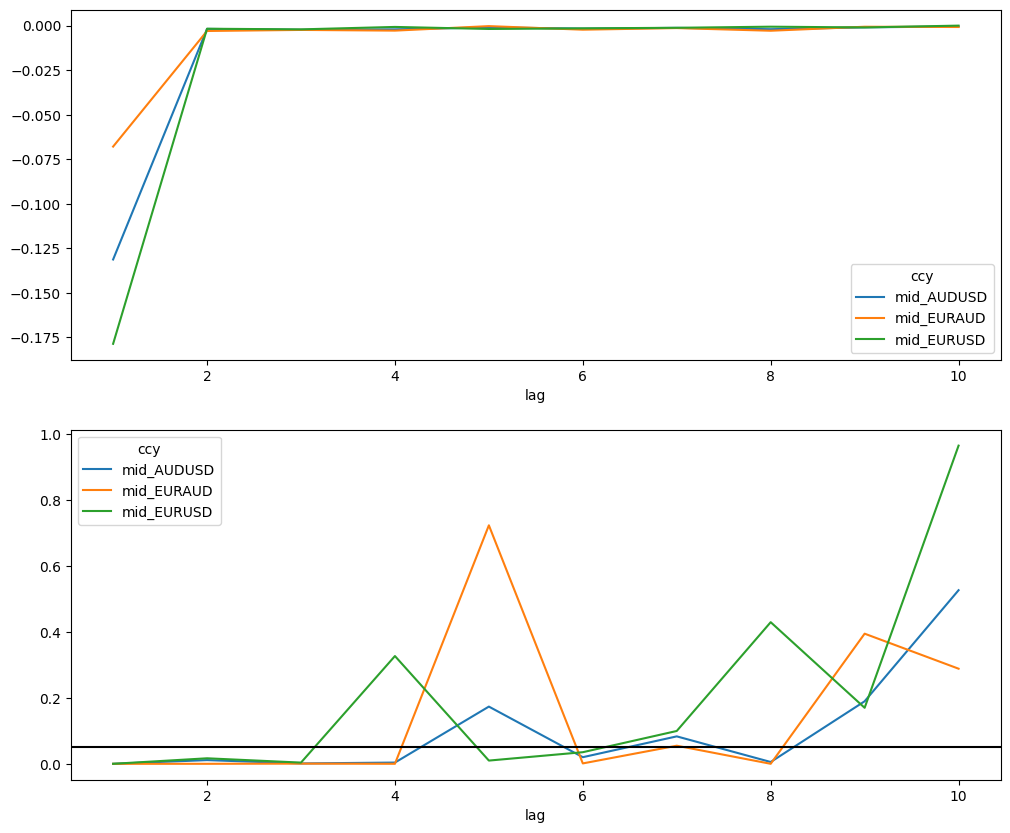

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

output_df.pivot(index='lag', columns='ccy', values='beta').loc[1:10].plot(ax=ax[0])
output_df.pivot(index='lag', columns='ccy', values='pval').loc[1:10].plot(ax=ax[1])
ax[1].axhline(0.05, color='black')

In [33]:
ccys = ['EURUSD', 'AUDUSD', 'EURAUD']
fld = 'mid'
windows = [1, 2, 3, 4, 5, 6, 7, 8]
signal = []
for w in windows:
    tmp_signal = mid_ret.rolling(window=w).mean().shift(+1)
    
    tmp_panel_signal = []
    for ccy in ccys:
        tmp_panel_signal.append(tmp_signal[[f'{fld}_{ccy}']].rename(columns={f'{fld}_{ccy}': ccy}))
        
    tmp_panel_signal = pd.concat(tmp_panel_signal, axis=1)
    tmp_panel_signal = tmp_panel_signal.reset_index()
    tmp_panel_signal = tmp_panel_signal.melt('date')
    tmp_panel_signal['fld'] = f'rmean{w}'
    tmp_panel_signal = tmp_panel_signal.rename(columns={'variable': 'ccy'})

    signal.append(tmp_panel_signal)
signal_df = pd.concat(signal, axis=0).pivot_table(index=['date', 'ccy'], columns='fld', values='value').reset_index()

In [34]:
ccys = ['EURUSD', 'AUDUSD', 'EURAUD']
fld = 'mid'
tmp_panel_mid_ret = []
for ccy in ccys:
    tmp_panel_mid_ret.append(mid_ret[[f'{fld}_{ccy}']].shift(-1).rename(columns={f'{fld}_{ccy}': ccy}))
return_tp1 = pd.concat(tmp_panel_mid_ret, axis=1)
return_tp1 = return_tp1.reset_index()
return_tp1 = return_tp1.melt('date')
return_tp1 = return_tp1.rename(columns={'value': 'return_tp1', 'variable': 'ccy'})

In [35]:
from sklearn.model_selection import train_test_split

backtest_mid = pd.merge(return_tp1, signal_df, on=['date', 'ccy']).dropna()

# define train and validation splits
train_mid_ret, val_mid_ret = train_test_split(mid_ret, test_size=0.2)
val_start_date = val_mid_ret.index[0]

#### 1. Sign-Based Alpha

In [36]:
signal_names = ['rmean1', 'rmean2', 'rmean3', 'rmean4', 'rmean5', 'rmean6', 'rmean7', 'rmean8']

train_backtest_mid_1 = backtest_mid.loc[backtest_mid['date'] < val_start_date].copy()
val_backtest_mid_1 = backtest_mid.loc[backtest_mid['date'] >= val_start_date].copy()

alpha1_portfolio_returns = []
val_alpha1_portfolio_returns = []
for sn in signal_names:
    train_backtest_mid_1[f'{sn}_pos'] = (np.sign(train_backtest_mid_1[sn]) * -1)
    
    train_backtest_mid_1[f'{sn}_return'] = train_backtest_mid_1[f'{sn}_pos'] * train_backtest_mid_1['return_tp1']
    tmp_signal_return = train_backtest_mid_1[['date', 'ccy', f'{sn}_return']].copy()
    tmp_signal_portfolio_return = tmp_signal_return.groupby(['date'])[[f'{sn}_return']].mean()
    alpha1_portfolio_returns.append(tmp_signal_portfolio_return)

    val_backtest_mid_1[f'{sn}_pos'] = (np.sign(val_backtest_mid_1[sn]) * -1)
    val_backtest_mid_1[f'{sn}_return'] = val_backtest_mid_1[f'{sn}_pos'] * val_backtest_mid_1['return_tp1']
    tmp_val_signal_return = val_backtest_mid_1[['date', 'ccy', f'{sn}_return']].copy()
    tmp_val_signal_portfolio_return = tmp_val_signal_return.groupby(['date'])[[f'{sn}_return']].mean()
    val_alpha1_portfolio_returns.append(tmp_val_signal_portfolio_return)

alpha1_portfolio_returns_df = pd.concat(alpha1_portfolio_returns, axis=1)
val_alpha1_portfolio_returns_df = pd.concat(val_alpha1_portfolio_returns, axis=1)

In [37]:
pd.DataFrame(
    {
        'Train': (alpha1_portfolio_returns_df.mean() / alpha1_portfolio_returns_df.std()) * np.sqrt(525960),
        'Val': (val_alpha1_portfolio_returns_df.mean() / val_alpha1_portfolio_returns_df.std()) * np.sqrt(525960),
    }
)

,Train,Val
rmean1_return,2.322339,1.701081
rmean2_return,2.758884,3.241163
rmean3_return,2.824021,4.610712
rmean4_return,3.052286,4.872573
rmean5_return,3.242978,6.014574
rmean6_return,3.233414,4.748294
rmean7_return,3.379906,5.073580
rmean8_return,3.620926,5.968870


<Axes: xlabel='date'>

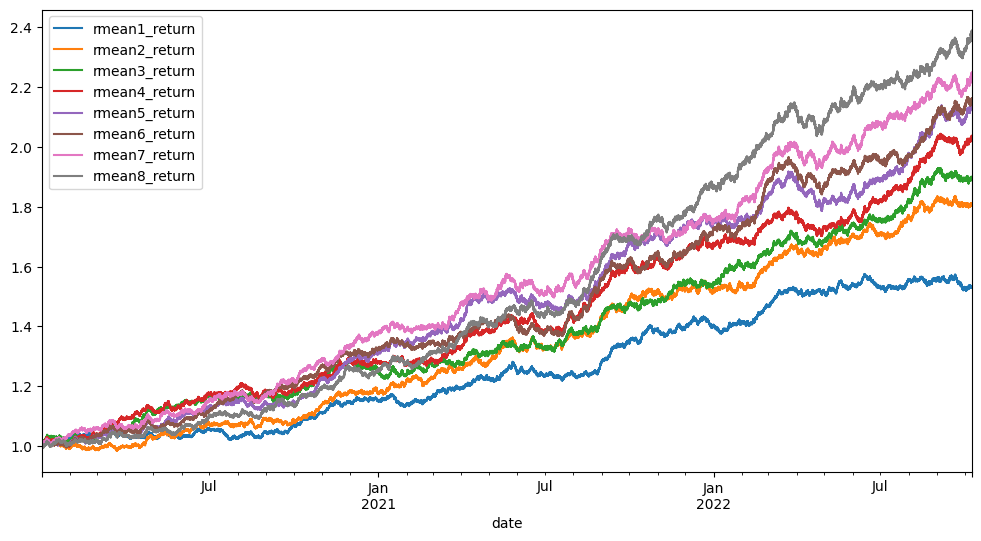

In [38]:
(1+alpha1_portfolio_returns_df).cumprod().plot(figsize=(12, 6))

#### 2. Tanh-Based Alpha

In [42]:
def tanh(x):
    return (np.exp(x) - np.exp(-x)) / np.exp(x) + np.exp(-x)

signal_names = ['rmean1', 'rmean2', 'rmean3', 'rmean4', 'rmean5', 'rmean6', 'rmean7', 'rmean8']

train_backtest_mid_2 = backtest_mid.loc[backtest_mid['date'] < val_start_date].copy()
val_backtest_mid_2 = backtest_mid.loc[backtest_mid['date'] >= val_start_date].copy()

alpha2_portfolio_returns = []
val_alpha2_portfolio_returns = []
for sn in signal_names:
    train_backtest_mid_2[f'{sn}_pos'] = (tanh(train_backtest_mid_2[sn] * -1))
    train_backtest_mid_2[f'{sn}_return'] = train_backtest_mid_2[f'{sn}_pos'] * train_backtest_mid_2['return_tp1']
    tmp_signal_return = train_backtest_mid_2[['date', 'ccy', f'{sn}_return']].copy()
    tmp_signal_portfolio_return = tmp_signal_return.groupby(['date'])[[f'{sn}_return']].mean()
    alpha2_portfolio_returns.append(tmp_signal_portfolio_return)

    val_backtest_mid_2[f'{sn}_pos'] = (tanh(val_backtest_mid_2[sn] * -1))
    val_backtest_mid_2[f'{sn}_return'] = val_backtest_mid_2[f'{sn}_pos'] * val_backtest_mid_2['return_tp1']
    tmp_val_signal_return = val_backtest_mid_2[['date', 'ccy', f'{sn}_return']].copy()
    tmp_val_signal_portfolio_return = tmp_val_signal_return.groupby(['date'])[[f'{sn}_return']].mean()
    val_alpha2_portfolio_returns.append(tmp_val_signal_portfolio_return)

alpha2_portfolio_returns_df = pd.concat(alpha2_portfolio_returns, axis=1)
val_alpha2_portfolio_returns_df = pd.concat(val_alpha2_portfolio_returns, axis=1)

In [43]:
pd.DataFrame(
    {
        'Train': (alpha2_portfolio_returns_df.mean() / alpha2_portfolio_returns_df.std()) * np.sqrt(525960),
        'Val': (val_alpha2_portfolio_returns_df.mean() / val_alpha2_portfolio_returns_df.std()) * np.sqrt(525960),
    }
)

,Train,Val
rmean1_return,0.180008,-0.284313
rmean2_return,0.179943,-0.284174
rmean3_return,0.179916,-0.284171
rmean4_return,0.179767,-0.284129
rmean5_return,0.179769,-0.284132
rmean6_return,0.179770,-0.284217
rmean7_return,0.179815,-0.284284
rmean8_return,0.179760,-0.284269


<Axes: xlabel='date'>

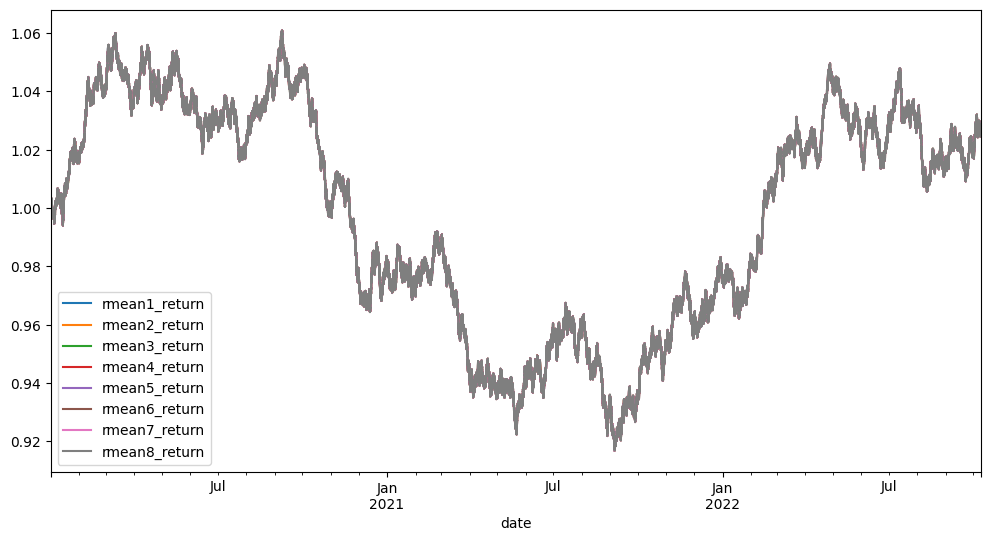

In [44]:
(1+alpha2_portfolio_returns_df).cumprod().plot(figsize=(12, 6))

#### 3. Model-Based Alpha - Random Forest

In [83]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

train_backtest_mid_3 = backtest_mid.loc[backtest_mid['date'] < val_start_date].copy()
val_backtest_mid_3 = backtest_mid.loc[backtest_mid['date'] >= val_start_date].copy()

# add fixed effects
train_fixed_effects = pd.get_dummies(train_backtest_mid_3['ccy']).astype(int)
train_backtest_mid_3 = pd.concat([train_backtest_mid_3, train_fixed_effects], axis=1)

val_fixed_effects = pd.get_dummies(val_backtest_mid_3['ccy']).astype(int)
val_backtest_mid_3 = pd.concat([val_backtest_mid_3, val_fixed_effects], axis=1)

y_train = train_backtest_mid_3['return_tp1'].values
X_train = train_backtest_mid_3.drop(['date', 'ccy', 'return_tp1'], axis=1)

y_val = val_backtest_mid_3['return_tp1'].values
X_val = val_backtest_mid_3.drop(['date', 'ccy', 'return_tp1'], axis=1)

rf_init = RandomForestRegressor(n_estimators=5, random_state=0, n_jobs=-1)
rf_init.fit(X_train, y_train)
y_rf_val_pred = rf_init.predict(X_val)

rf_val_mse = mean_squared_error(y_val, y_rf_val_pred)

print(f"RF n_estimators=5 MSE = {rf_val_mse}")

KeyboardInterrupt: 

In [ ]:
rf_init = RandomForestRegressor(n_estimators=50, random_state=0, n_jobs=-1)
rf_init.fit(X_train, y_train)
y_rf_val_pred = rf_init.predict(X_val)

rf_val_mse = mean_squared_error(y_val, y_rf_val_pred)

print(f"R with n_estimators = 50 MSE = {rf_val_mse}")

,rmean1,rmean2,rmean3,rmean4,rmean5,rmean6,rmean7,rmean8,AUDUSD,EURAUD,EURUSD
7,-0.000200,-0.000200,-1.331203e-04,-9.984026e-05,-0.000080,-0.000033,-0.000029,-2.495757e-05,0,0,1
8,0.000000,-0.000100,-1.331203e-04,-9.984026e-05,-0.000080,-0.000067,-0.000029,-2.495757e-05,0,0,1
9,0.000200,0.000100,1.329608e-08,-4.990517e-05,-0.000040,-0.000033,-0.000029,9.970068e-09,0,0,1
10,0.000000,0.000100,6.658011e-05,9.972059e-09,-0.000040,-0.000033,-0.000029,-2.495259e-05,0,0,1
11,-0.000200,-0.000100,1.329608e-08,9.972059e-09,-0.000040,-0.000067,-0.000057,-4.991514e-05,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
5661672,-0.000163,-0.000081,8.821701e-09,6.616276e-09,-0.000130,-0.000081,-0.000070,-2.029710e-05,0,1,0
5661673,-0.000163,-0.000163,-1.084540e-04,-4.066694e-05,-0.000033,-0.000136,-0.000093,-8.130082e-05,0,1,0
5661674,-0.000325,-0.000244,-2.169344e-04,-1.627008e-04,-0.000098,-0.000081,-0.000163,-1.219810e-04,0,1,0
5661675,-0.000163,-0.000244,-2.169698e-04,-2.033943e-04,-0.000163,-0.000108,-0.000093,-1.626546e-04,0,1,0


In [ ]:
rf_init = RandomForestRegressor(
    n_estimators=50, # number of trees in the forest
    random_state=0, 
    n_jobs=-1
)
rf_init.fit(X_train, y_train)
y_rf_val_pred = rf_init.predict(X_val)

rf_val_mse = mean_squared_error(y_val, y_rf_val_pred)

print(f"R with n_estimators = 50 MSE = {rf_val_mse}")

,rmean1,rmean2,rmean3,rmean4,rmean5,rmean6,rmean7,rmean8,AUDUSD,EURAUD,EURUSD
1456879,0.000197,1.942855e-08,1.295236e-08,-4.925622e-05,-3.940498e-05,-3.283748e-05,-0.000028,-0.000025,0,0,1
1456880,-0.000197,1.942855e-08,-6.568791e-05,-4.926593e-05,-7.882550e-05,-6.568791e-05,-0.000056,-0.000049,0,0,1
1456881,0.000000,-9.855130e-05,1.295236e-08,-4.926593e-05,-3.941275e-05,-6.568791e-05,-0.000056,-0.000049,0,0,1
1456882,0.000197,9.857072e-05,1.295236e-08,4.929508e-05,1.554284e-08,1.295236e-08,-0.000028,-0.000025,0,0,1
1456883,-0.000197,1.942855e-08,1.295236e-08,-4.926593e-05,1.554284e-08,-3.283748e-05,-0.000028,-0.000049,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
6307191,-0.000211,2.217000e-08,1.478000e-08,1.053519e-04,1.264267e-04,1.404840e-04,0.000181,0.000105,0,1,0
6307192,0.000000,-1.052742e-04,1.478000e-08,1.108500e-08,8.428149e-05,1.053556e-04,0.000120,0.000158,0,1,0
6307193,-0.000211,-1.052964e-04,-1.403804e-04,-5.263712e-05,-4.210970e-05,3.513577e-05,0.000060,0.000079,0,1,0
6307194,0.000211,2.217934e-08,1.478623e-08,-5.262603e-05,1.773973e-08,1.478311e-08,0.000060,0.000079,0,1,0


In [ ]:
rf_init = RandomForestRegressor(
    n_estimators=50,        # number of trees in the forest
    min_samples_leaf=2,     # number of min examples on each node of the tree (larger is good for small datasets usually)
    random_state=0, 
    n_jobs=-1
)
rf_init.fit(X_train, y_train)
y_rf_val_pred = rf_init.predict(X_val)

rf_val_mse = mean_squared_error(y_val, y_rf_val_pred)

print(f"R with n_estimators = 50 MSE = {rf_val_mse}")